In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

import os

In [3]:
print(os.getcwd())

/Users/bryancruz/Documents/UCSD/6th Quarter/DSC 148/Wave Power Project/notebooks


# Wave Energy Converter Farm Optimization

## 1. Introduction

From UCI's Machine Learning Repository Datasets Site: Wave energy is a rapidly advancing and promising renewable energy source that holds great potential for addressing the challenges of global warming and climate change. However, optimizing energy output in large wave farms presents a complex problem due to the expensive calculations required to account for hydrodynamic interactions between wave energy converters (WECs). Developing a fast and accurate surrogate model is crucial to overcome these challenges. In light of this, we have compiled an extensive WEC dataset that includes 54,000 and 9,600 configurations involving 49 and 100 WECs, coordination, power, q-factor, and total farm power output. The dataset was derived from a study published at the GECCO conference and received the prestigious Best Paper award.

## 2. Data Loading and Problem Definition

The dataset includes 4 CSV files for 49 and 100 wave energy converters based on Perth and Sydney wave scenarios. The main goal is predicting the total power output of the wave farm based on the coordination of WECs (X1, Y1, X2, Y2,..., Xn, Yn).

In [4]:
df = pd.read_csv("../data/WEC/WEC_Sydney_49.csv")
df.head()

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
0,1.0,1.0,0.00,70.00,1.00,140.0,50.00,198.0,401.0,1.0,...,71909.82,70674.49,70972.33,90957.03,90903.63,87876.82,79499.23,68880.39,0.78,4065416.61
1,598.0,0.0,595.82,77.69,593.70,150.0,549.00,198.0,798.0,0.0,...,68757.68,70665.50,69963.48,84511.25,85691.70,85211.51,76678.20,76119.53,0.76,3951216.37
2,198.0,0.0,197.46,75.19,192.94,150.0,87.64,198.0,398.0,0.0,...,73675.80,77808.44,73519.82,91436.35,88770.60,86632.78,77932.46,69343.12,0.78,4022640.78
3,598.0,0.0,596.97,69.41,592.69,143.8,549.00,198.0,398.0,200.0,...,68947.21,71668.05,69380.67,85191.27,84453.12,85300.41,78573.25,72527.16,0.75,3879223.41
4,198.0,0.0,197.18,79.83,192.97,150.0,89.53,198.0,398.0,0.0,...,78367.97,79075.06,74354.03,85254.75,86978.69,86951.65,77671.87,74901.38,0.77,3974691.24


In [6]:
# shape and columns
print(df.shape)
print(df.columns)

(17964, 149)
Index(['X1', 'Y1', 'X2', 'Y2', 'X3', 'Y3', 'X4', 'Y4', 'X5', 'Y5',
       ...
       'Power42', 'Power43', 'Power44', 'Power45', 'Power46', 'Power47',
       'Power48', 'Power49', 'qW', 'Total_Power'],
      dtype='object', length=149)


In [7]:
y = df["Total_Power"]

I did not include Total_Power, and I left out the individual Power columns at first because they may make the task too easy or leaky

In [9]:
# Only X and Y coordinate columns
coord_cols = [col for col in df.columns if col.startswith("X") or col.startswith("Y")]

X = df[coord_cols]
y = df["Total_Power"]

print(X.shape)
print(y.shape)

(17964, 98)
(17964,)


## 3. Baseline Models

In [ ]:
# Split off the test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size = 0.15,
    random_state = 42
)

# Split train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.1765,  
    random_state = 42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (12574, 98)
Validation shape: (2695, 98)
Test shape: (2695, 98)


In [11]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    model.fit(X_train, y_train)
    
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)
    
    results = {
        "Model": model_name,
        "Train MAE": mean_absolute_error(y_train, train_preds),
        "Val MAE": mean_absolute_error(y_val, val_preds),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_preds)),
        "Val RMSE": np.sqrt(mean_squared_error(y_val, val_preds)),
        "Train R2": r2_score(y_train, train_preds),
        "Val R2": r2_score(y_val, val_preds)
    }
    
    return results

In [12]:
dummy = DummyRegressor(strategy = "mean")

dummy_results = evaluate_model(
    dummy,
    X_train, y_train,
    X_val, y_val,
    "Dummy Baseline"
)

dummy_results

{'Model': 'Dummy Baseline',
 'Train MAE': np.float64(57598.850370749875),
 'Val MAE': np.float64(59134.07151174541),
 'Train RMSE': np.float64(70151.68030609826),
 'Val RMSE': np.float64(72097.97255802253),
 'Train R2': 0.0,
 'Val R2': -0.0013957253846117457}

In [13]:
linear = LinearRegression()

linear_results = evaluate_model(
    linear,
    X_train, y_train,
    X_val, y_val,
    "Linear Regression"
)

linear_results

{'Model': 'Linear Regression',
 'Train MAE': np.float64(15967.40824859689),
 'Val MAE': np.float64(16395.9271661271),
 'Train RMSE': np.float64(23194.278999982653),
 'Val RMSE': np.float64(23534.49600610381),
 'Train R2': 0.8906835303035994,
 'Val R2': 0.8932987681617635}

In [14]:
rf = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 20,
    min_samples_split = 5,
    random_state = 42,
    n_jobs = -1
)

rf_results = evaluate_model(
    rf,
    X_train, y_train,
    X_val, y_val,
    "Random Forest"
)

rf_results

{'Model': 'Random Forest',
 'Train MAE': np.float64(1624.6221254922427),
 'Val MAE': np.float64(3669.1001497566604),
 'Train RMSE': np.float64(4812.1502287258),
 'Val RMSE': np.float64(10284.594921432676),
 'Train R2': 0.9952945387848905,
 'Val R2': 0.9796232925449673}

In [15]:
gb = GradientBoostingRegressor(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 3,
    random_state = 42
)

gb_results = evaluate_model(
    gb,
    X_train, y_train,
    X_val, y_val,
    "Gradient Boosting"
)

gb_results

{'Model': 'Gradient Boosting',
 'Train MAE': np.float64(7411.203114710392),
 'Val MAE': np.float64(8003.263287859956),
 'Train RMSE': np.float64(10818.79351864117),
 'Val RMSE': np.float64(12157.527717105695),
 'Train R2': 0.9762161855244061,
 'Val R2': 0.9715258895421598}

In [16]:
hgb = HistGradientBoostingRegressor(
    max_iter = 500,
    learning_rate = 0.05,
    max_leaf_nodes = 31,
    random_state = 42
)

hgb_results = evaluate_model(
    hgb,
    X_train, y_train,
    X_val, y_val,
    "Hist Gradient Boosting"
)

hgb_results

{'Model': 'Hist Gradient Boosting',
 'Train MAE': np.float64(2068.321908444285),
 'Val MAE': np.float64(3488.2036146253636),
 'Train RMSE': np.float64(4047.1445360632024),
 'Val RMSE': np.float64(7236.105213681094),
 'Train R2': 0.9966717091311851,
 'Val R2': 0.9899128291996219}

In [17]:
results_df = pd.DataFrame([
    dummy_results,
    linear_results,
    rf_results,
    gb_results,
    hgb_results
])

results_df.sort_values("Val MAE")

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2
4,Hist Gradient Boosting,2068.321908,3488.203615,4047.144536,7236.105214,0.996672,0.989913
2,Random Forest,1624.622125,3669.100150,4812.150229,10284.594921,0.995295,0.979623
3,Gradient Boosting,7411.203115,8003.263288,10818.793519,12157.527717,0.976216,0.971526
1,Linear Regression,15967.408249,16395.927166,23194.279000,23534.496006,0.890684,0.893299
0,Dummy Baseline,57598.850371,59134.071512,70151.680306,72097.972558,0.000000,-0.001396


In [18]:
best_model = HistGradientBoostingRegressor(
    max_iter = 500,
    learning_rate = 0.05,
    max_leaf_nodes = 31,
    random_state = 42
)

# Combine train and validation
X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

# Retrain all training data
best_model.fit(X_full_train, y_full_train)

test_preds = best_model.predict(X_test)

print("Final Test MAE:",
      mean_absolute_error(y_test, test_preds))

print("Final Test RMSE:",
      np.sqrt(mean_squared_error(y_test, test_preds)))

print("Final Test R2:",
      r2_score(y_test, test_preds))

Final Test MAE: 3290.600099201497
Final Test RMSE: 6988.124837757876
Final Test R2: 0.9905398869780714


Hist Gradient Boosting performed best overall, with the lowest validation MAE and the highest validation R². This seems to suggest that it captured the relationship between WEC farm layouts and Total_Power better than the other models. 

In [20]:
# raw coordinate features
X_raw = df[coord_cols]

X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y, test_size = 0.15, random_state = 42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size = 0.1765, random_state = 42
)

rf_raw = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 20,
    min_samples_split = 5,
    random_state = 42,
    n_jobs = -1
)

rf_raw_results = evaluate_model(
    rf_raw,
    X_train, y_train,
    X_val, y_val,
    "RF Raw Coordinates"
)

hgb_raw = HistGradientBoostingRegressor(
    max_iter = 500,
    learning_rate = 0.05,
    max_leaf_nodes = 31,
    random_state = 42
)

hgb_raw_results = evaluate_model(
    hgb_raw,
    X_train, y_train,
    X_val, y_val,
    "HGB Raw Coordinates"
)

## 4. Geometry Feature Engineering

In [24]:
def add_geometry_features(df, n_devices=49):

    df = df.copy()

    x_cols = [f"X{i}" for i in range(1, n_devices + 1)]
    y_cols = [f"Y{i}" for i in range(1, n_devices + 1)]

    X_vals = df[x_cols].values
    Y_vals = df[y_cols].values

    # centroid
    df["centroid_x"] = X_vals.mean(axis = 1)
    df["centroid_y"] = Y_vals.mean(axis = 1)

    # spread
    df["x_std"] = X_vals.std(axis = 1)
    df["y_std"] = Y_vals.std(axis = 1)

    # range
    df["x_range"] = X_vals.max(axis = 1) - X_vals.min(axis = 1)
    df["y_range"] = Y_vals.max(axis = 1) - Y_vals.min(axis = 1)

    # distance from center
    cx = X_vals.mean(axis = 1).reshape(-1, 1)
    cy = Y_vals.mean(axis = 1).reshape(-1, 1)

    distances = np.sqrt((X_vals - cx)**2 + (Y_vals - cy)**2)

    df["mean_dist_center"] = distances.mean(axis = 1)
    df["max_dist_center"] = distances.max(axis = 1)

    return df

In [25]:
df_fe = add_geometry_features(df, n_devices = 49)

coord_cols = [
    col for col in df_fe.columns
    if col.startswith("X") or col.startswith("Y")
]

geometry_cols = [
    "centroid_x",
    "centroid_y",
    "x_std",
    "y_std",
    "x_range",
    "y_range",
    "mean_dist_center",
    "max_dist_center"
]

X = df_fe[coord_cols + geometry_cols]
y = df_fe["Total_Power"]

In [26]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size = 0.15, random_state = 42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size = 0.1765, random_state = 42
)

rf = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 20,
    min_samples_split = 5,
    random_state = 42,
    n_jobs = -1
)

rf_results = evaluate_model(
    rf,
    X_train, y_train,
    X_val, y_val,
    "Random Forest with Geometry Features"
)

rf_results

{'Model': 'Random Forest with Geometry Features',
 'Train MAE': np.float64(1030.5013350109232),
 'Val MAE': np.float64(2731.0790317143683),
 'Train RMSE': np.float64(2822.477908665799),
 'Val RMSE': np.float64(7276.798863054632),
 'Train R2': 0.9983812307461652,
 'Val R2': 0.9897990558374585}

In [27]:
hgb = HistGradientBoostingRegressor(
    max_iter = 500,
    learning_rate = 0.05,
    max_leaf_nodes = 31,
    random_state = 42
)

hgb_results = evaluate_model(
    hgb,
    X_train, y_train,
    X_val, y_val,
    "Hist Gradient Boosting with Geometry Features"
)

hgb_results

{'Model': 'Hist Gradient Boosting with Geometry Features',
 'Train MAE': np.float64(1580.6024855865203),
 'Val MAE': np.float64(2777.122817859715),
 'Train RMSE': np.float64(2721.691186023182),
 'Val RMSE': np.float64(5694.674421614905),
 'Train R2': 0.9984947746011045,
 'Val R2': 0.9937526271249945}

In [28]:
pd.DataFrame([rf_results, hgb_results])

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2
0,Random Forest with Geometry Features,1030.501335,2731.079032,2822.477909,7276.798863,0.998381,0.989799
1,Hist Gradient Boosting with Geometry Features,1580.602486,2777.122818,2721.691186,5694.674422,0.998495,0.993753


After adding geometry features, both the Random Forest and Hist Gradient Boosting models performed pretty well. Random Forest got a slightly lower validation MAE, showing a smaller average prediction error. However, the Hist Gradient Boosting model had a much lower validation RMSE and a higher validation R². Since RMSE puts more emphasis on larger errors, the results suggest that Hist Gradient Boosting is making fewer large prediction mistakes. Because of this, Hist Gradient Boosting was selected as the stronger final model with geometry features.

## 5. Feature Importance Analysis

Since Hist Gradient Boosting was selected as the final model, permutation importance was used to see which features had the greatest influence on its predictions.

In [29]:
result = permutation_importance(
    hgb,
    X_val,
    y_val,
    n_repeats = 10,
    random_state = 42,
    scoring = "neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": result.importances_mean
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
104,mean_dist_center,24540.504977
100,x_std,16212.441084
101,y_std,5387.361586
0,X1,3858.118601
102,x_range,3246.539099
6,X4,2112.763085
98,centroid_x,1094.402710
51,Y26,1046.116907
92,X47,896.643574
70,X36,879.700665


In [30]:
rf_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

rf_importance_df = rf_importance_df.sort_values("Importance", ascending = False)

rf_importance_df.head(15)

,Feature,Importance
100,x_std,0.432831
104,mean_dist_center,0.430261
102,x_range,0.032200
101,y_std,0.025945
0,X1,0.009682
2,X2,0.005532
77,Y39,0.004566
4,X3,0.002683
51,Y26,0.002530
46,X24,0.002270


The permutation importance results for Hist Gradient Boosting show that the most influential predictors are the geometry-based features and the one in particularly are mean_dist_center, x_std, y_std, and x_range. This means that the overall spread and structure of the WEC farm layout may have a big impact on power production than most individual turbine coordinates. Also, the Random Forest feature importance results showed a similar pattern as well that futher supports the idea that spatial dispersion is a key factor in predicting the total power output.

### Figure 1: Hist Gradient Boosting Feature Importance for Predicting Total_Power

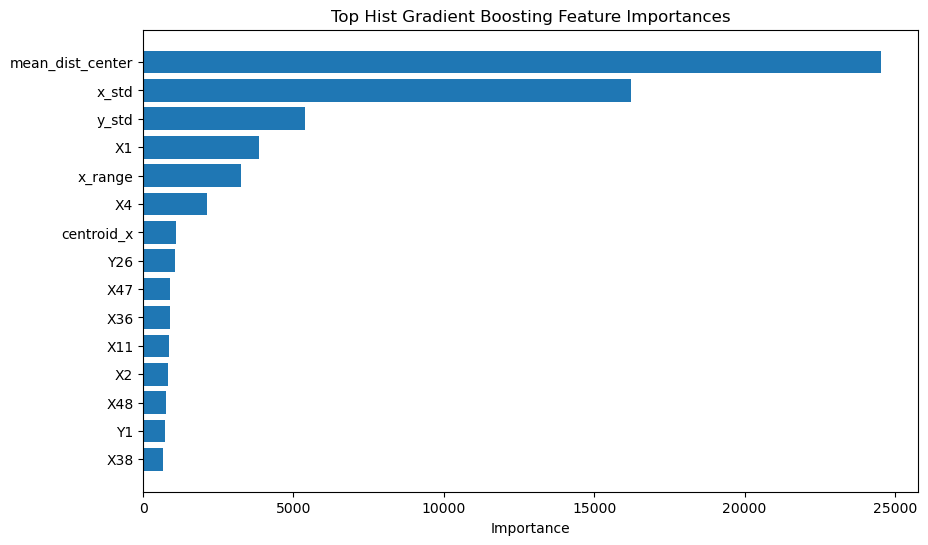

In [31]:
top_features = importance_df.head(15)

plt.figure(figsize = (10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top Hist Gradient Boosting Feature Importances")
plt.show()

This figure shows the permutation importance values for the Hist Gradient Boosting model. As the figure shows that geometry-based features dominate the rankings, with mean_dist_center and x_std having the largest impact on prediction accuracy. The results seem to suggest that farm spacing and the layout structure are more important than individual turbine coordinates when predicting total power output.

### Key Finding

The Hist Gradient Boosting model relies mostly on engineered geometry features rather than just individual turbine coordinates.

The two most important features were:

- "mean_dist_center"
- "x_std"

These features is describing the overall spread of the WEC farm and how far turbines are positioned from the farm center. This means that the overall farm geometry has a greater influence on Total_Power than just the exact location of any single device. In particular, it shows that both the average distance from the farm center and the variation of turbine positions along the x-direction play huge roles in determining the power production. So the large influence of these engineered geometry features shows the value of feature engineering. It also helps explain why the model performance improved greatly after they're introduced.


## 6. Correlation Analysis

Several of the more important geometry features describe aspects that are similar of the farm layout. For example, x_std and mean_dist_center both measure how spread out the turbines are and are most likely to be strongly correlated. So, examining the relationships between these features can help determine if they can provide any unique information or are just capturing the same underlying characteristics.

In [32]:
df_fe[["x_std", "mean_dist_center", "x_range", "y_std"]].corr()

,x_std,mean_dist_center,x_range,y_std
x_std,1.000000,0.947353,0.175212,0.488687
mean_dist_center,0.947353,1.000000,0.157200,0.721003
x_range,0.175212,0.157200,1.000000,0.091318
y_std,0.488687,0.721003,0.091318,1.000000


The correlation analysis here showed that x_std and mean_dist_center were highly correlated (0.947), which indicates that both features capture similar aspects of the WEC farm layout. Helps explain why they were identified as the two most important features in the Hist Gradient Boosting model. The results also shows that the model relies more on the overall spatial dispersion of the turbines more than the individual turbine coordinates when predicting Total_Power.

### Figure 2: Correlation Matrix of Engineered Geometry Features

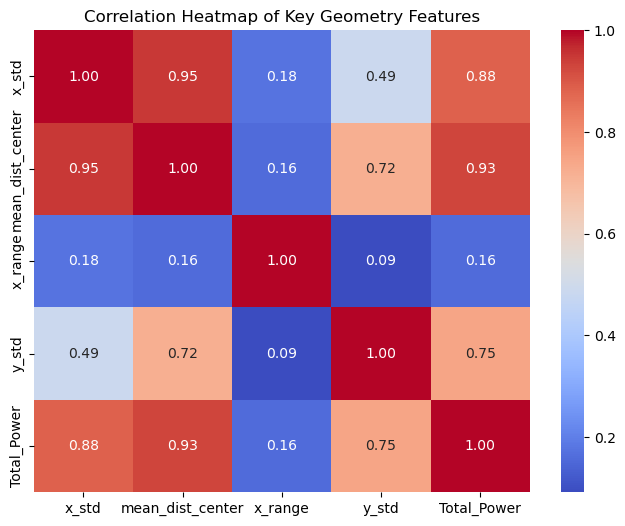

In [33]:
top_geom = df_fe[
    ["x_std", "mean_dist_center",
     "x_range", "y_std", "Total_Power"]
]

plt.figure(figsize = (8,6))

sns.heatmap(
    top_geom.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Key Geometry Features")
plt.show()

The correlation heatmap shows several geometry-based features are strongly related to Total_Power. The strongest relationships observed were mean_dist_center (0.93) and x_std (0.88), indicating that farms with more spread-out turbine layouts tend to produce more power.

The heatmap also shows a very strong correlation (0.95) between mean_dist_center and x_std, which could suggest that both features capture similar aspects of the farm's geometry. This matches what we got for the feature importance results from the Hist Gradient Boosting model, where these same features were identified as the most important predictors. Overall, the results show that turbine spacing and overall farm layout are the key factors in WEC farm performance.

## 7. Model Comparison

In [35]:
comparison_df = pd.DataFrame([
    {
        "Model": "RF Raw Coordinates",
        "Val MAE": rf_raw_results["Val MAE"],
        "Val RMSE": rf_raw_results["Val RMSE"],
        "Val R2": rf_raw_results["Val R2"]
    },

    {
        "Model": "RF + Geometry Features",
        "Val MAE": rf_results["Val MAE"],
        "Val RMSE": rf_results["Val RMSE"],
        "Val R2": rf_results["Val R2"]
    },

    {
        "Model": "HGB Raw Coordinates",
        "Val MAE": hgb_raw_results["Val MAE"],
        "Val RMSE": hgb_raw_results["Val RMSE"],
        "Val R2": hgb_raw_results["Val R2"]
    },

    {
        "Model": "HGB + Geometry Features",
        "Val MAE": hgb_results["Val MAE"],
        "Val RMSE": hgb_results["Val RMSE"],
        "Val R2": hgb_results["Val R2"]
    }
])

comparison_df.sort_values("Val RMSE")

,Model,Val MAE,Val RMSE,Val R2
3,HGB + Geometry Features,2777.122818,5694.674422,0.993753
2,HGB Raw Coordinates,3488.203615,7236.105214,0.989913
1,RF + Geometry Features,2731.079032,7276.798863,0.989799
0,RF Raw Coordinates,3669.100150,10284.594921,0.979623


Adding geometry features improved the performance of both the Random Forest and Hist Gradient Boosting Model. For Random Forest, the validation MAE decreased from about 3669 to 2731. This is showing that the geometry-based features use more useful information than the raw turbine coordinates alone.

Even Hist Gradient Boosting also improved after feature engineering. The validation MAE decreased from 3488 to 2777, while the RMSE dropped from 7236 to 5695 and R² increased from 0.9899 to 0.9938. This seems to suggest that the geometry features helped the model better capture the relationship between farm layout and power production.

Overall, the Hist Gradient Boosting with geometry features achieved the best performance and is why it's selected as the final model.

In [36]:
hgb_mae_pct = (
    hgb_results["Val MAE"] / y.mean()
) * 100

print(f"Percent Error: {hgb_mae_pct:.3f}%")

Percent Error: 0.069%


In [37]:
# X includes raw coordinates and geometry features
X = df_fe[coord_cols + geometry_cols]
y = df_fe["Total_Power"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size = 0.15,
    random_state = 42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.1765,
    random_state = 42
)

# Retrain HGB on geometry-feature data
hgb = HistGradientBoostingRegressor(
    max_iter = 500,
    learning_rate = 0.05,
    max_leaf_nodes = 31,
    random_state = 42
)

hgb.fit(X_train, y_train)

hgb_test_preds = hgb.predict(X_test)

### Figure 3: Hist Gradient Boosting Predicted vs Actual Total_Power Values

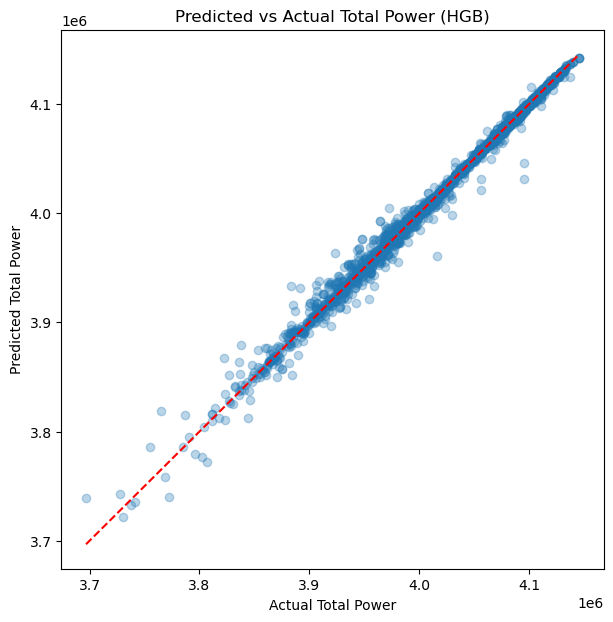

In [ ]:
hgb_preds = hgb.predict(X_test)

plt.figure(figsize = (7,7))

plt.scatter(y_test, hgb_preds, alpha = 0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Total Power")
plt.ylabel("Predicted Total Power")
plt.title("Predicted vs Actual Total Power (HGB)")

plt.show()

This scatterplot compares predicted and actual Total_Power values for the Hist Gradient Boosting model on the test set. The predicted-versus-actual plot shows that the Hist Gradient Boosting model predicts Total_Power with high accuracy across the full range of observed values. Most points seem to lie pretty close to the diagonal line, which is an indication of a strong agreement between the predicted and actual power output.

Only a minor number of observations differ noticeably from the line, most likely meaning that the large prediction errors are uncommon. The model performs well across both the lower- and higher-power farm layouts, which is common with its high R² (0.9938) and it's low RMSE.

Overall, these results show that Hist Gradient Boosting is an effective model for predicting the WEC farm power production from any turbine layout information. The validation MAE corresponds to approximately 0.069% of the mean Total_Power value, meaning that a very small prediction errors are relative to the scale of the target variable.


### Figure 4: Residual Plot for Hist Gradient Boosting Predictions

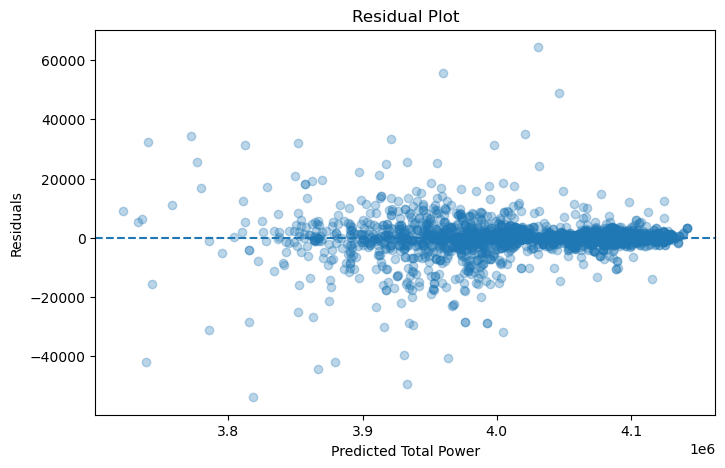

In [39]:
residuals = y_test - hgb_preds

plt.figure(figsize = (8,5))

plt.scatter(hgb_preds, residuals, alpha=0.3)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Total Power")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

This residual plot shows the difference between the observed and predicted Total_Power values. The residual plot shows that prediction errors are centered around zero, explainging that the model is not consistently overpredicting or underpredicting the Total_Power. Most residuals are small and evenly distributed, meaning the model performs well across the different farm layouts.

While a few larger errors are present of course, no clear patterns appear in the residuals. Overall, the residual analysis shows support for the strong performance shown by the Hist Gradient Boosting model.

### Table: Training and Validation Performance Comparison Across Models

This table compares training and validation performance for all the models tested. The tree-based ensemble methods outperform the baseline and linear models greatly, indicating that the relationship between WEC farm geometry and Total_Power isn't represented well by a simple linear model.

In [40]:
results_df["MAE Gap"] = ( 
    results_df["Val MAE"] - results_df["Train MAE"] 
    ) 

results_df.sort_values("MAE Gap")

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,MAE Gap
1,Linear Regression,15967.408249,16395.927166,23194.279000,23534.496006,0.890684,0.893299,428.518918
3,Gradient Boosting,7411.203115,8003.263288,10818.793519,12157.527717,0.976216,0.971526,592.060173
4,Hist Gradient Boosting,2068.321908,3488.203615,4047.144536,7236.105214,0.996672,0.989913,1419.881706
0,Dummy Baseline,57598.850371,59134.071512,70151.680306,72097.972558,0.000000,-0.001396,1535.221141
2,Random Forest,1624.622125,3669.100150,4812.150229,10284.594921,0.995295,0.979623,2044.478024


Hist Gradient Boosting and Random Forest achieved the best performance among all models tested. Both  outperformed the Dummy Baseline, Linear Regression, and standard Gradient Boosting models by a large margin and shows that the nonlinear methods are much better suited for predicting WEC power output.

While Random Forest got a slightly lower validation MAE than Hist Gradient Boosting, it also had a bigger gap between training and validation performance, which seems like a tendency to overfit. Hist Gradient Boosting achieved a lower validation RMSE, a higher R², and is more consistent with performance between the training and validation.

Hist Gradient Boosting provided the best balance between accuracy and generalization and shows why we selected it as the final model.

## 8. Cross Validation

In [ ]:
scores = cross_val_score(
    hgb,
    X,
    y,
    cv = 5,
    scoring = "neg_mean_absolute_error",
    n_jobs = -1
)

scores = -scores

print("CV MAE Scores:", scores)
print("Mean CV MAE:", scores.mean())
print("Std CV MAE:", scores.std())

CV MAE Scores: [2631.08116454 2688.20786947 2683.52239081 2613.90362942 2679.37474369]
Mean CV MAE: 2659.2179595884436
Std CV MAE: 30.60223505311391


Exception ignored in: <function ResourceTracker.__del__ at 0x10a321580>
Traceback (most recent call last):
  File "/Users/bryancruz/miniforge3/envs/dsc80/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/bryancruz/miniforge3/envs/dsc80/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/bryancruz/miniforge3/envs/dsc80/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103351580>
Traceback (most recent call last):
  File "/Users/bryancruz/miniforge3/envs/dsc80/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/bryancruz/miniforge3/envs/dsc80/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/bryancruz/miniforge3/envs/dsc80/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProc

### Cross Validation Results

**5-Fold Cross Validation**

Mean MAE: 2659.22

Standard Deviation: 30.60

**Interpretation**

Five-fold cross-validation produced a mean MAE of 2659.22 with a standard deviation of only 30.60. The low variation across the folds indicates that model performance is consistent and isn't heavily dependent on a particular train-validation set.

The results here show that the Hist Gradient Boosting model is generalizing well to unseen WEC farm layouts and gives reliable predictions across different subsets of the data.

## 9. Dataset Generalization Analysis
    - Sydney vs Perth
    - 49 vs 100 Device Farms

In [46]:
sydney_49 = pd.read_csv("../data/WEC/WEC_Sydney_49.csv")
sydney_100 = pd.read_csv("../data/WEC/WEC_Sydney_100.csv")
perth_49 = pd.read_csv("../data/WEC/WEC_Perth_49.csv")
perth_100 = pd.read_csv("../data/WEC/WEC_Perth_100.csv")

df_all = pd.concat([sydney_49, sydney_100, perth_49, perth_100], ignore_index=True)

In [47]:
def run_hgb_pipeline(df, n_devices, label):

    df = add_geometry_features(df, n_devices)

    coord_cols = [
        col for col in df.columns
        if col.startswith("X") or col.startswith("Y")
    ]

    geometry_cols = [
        "centroid_x",
        "centroid_y",
        "x_std",
        "y_std",
        "x_range",
        "y_range",
        "mean_dist_center",
        "max_dist_center"
    ]

    X = df[coord_cols + geometry_cols]
    y = df["Total_Power"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size = 0.2,
        random_state = 42
    )

    hgb = HistGradientBoostingRegressor(
        max_iter = 500,
        learning_rate = 0.05,
        max_leaf_nodes = 31,
        random_state = 42
    )

    hgb.fit(X_train, y_train)

    preds = hgb.predict(X_test)

    results = {
        "Dataset": label,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
        "Percent_Error": (
            mean_absolute_error(y_test, preds) / y.mean()
        ) * 100
    }

    return results

In [48]:
hgb_comparison_results = []

hgb_comparison_results.append(
    run_hgb_pipeline(perth_49, 49, "Perth 49")
)

hgb_comparison_results.append(
    run_hgb_pipeline(sydney_49, 49, "Sydney 49")
)

hgb_comparison_results.append(
    run_hgb_pipeline(perth_100, 100, "Perth 100")
)

hgb_comparison_results.append(
    run_hgb_pipeline(sydney_100, 100, "Sydney 100")
)

hgb_comparison_df = pd.DataFrame(hgb_comparison_results)

hgb_comparison_df

,Dataset,MAE,RMSE,R2,Percent_Error
0,Perth 49,10218.295262,21468.429677,0.968728,0.259463
1,Sydney 49,2728.289889,5485.446712,0.994144,0.067757
2,Perth 100,14418.215630,33287.580053,0.969913,0.203049
3,Sydney 100,8722.920997,18246.875612,0.965929,0.121706


In [49]:
def run_rf_pipeline(df, n_devices, label):

    df = add_geometry_features(df, n_devices)

    coord_cols = [
        col for col in df.columns
        if col.startswith("X") or col.startswith("Y")
    ]

    geometry_cols = [
        "centroid_x",
        "centroid_y",
        "x_std",
        "y_std",
        "x_range",
        "y_range",
        "mean_dist_center",
        "max_dist_center"
    ]

    X = df[coord_cols + geometry_cols]
    y = df["Total_Power"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size = 0.2,
        random_state = 42
    )

    rf = RandomForestRegressor(
        n_estimators = 200,
        max_depth = 20,
        min_samples_split = 5,
        random_state = 42,
        n_jobs = -1
    )

    rf.fit(X_train, y_train)

    preds = rf.predict(X_test)

    results = {
    "Dataset": label,
    "MAE": mean_absolute_error(y_test, preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
    "R2": r2_score(y_test, preds),
    "Percent_Error": (
        mean_absolute_error(y_test, preds) / y.mean()
    ) * 100
}

    return results  

In [50]:
comparison_results = []

comparison_results.append(
    run_rf_pipeline(perth_49, 49, "Perth 49")
)

comparison_results.append(
    run_rf_pipeline(sydney_49, 49, "Sydney 49")
)

comparison_results.append(
    run_rf_pipeline(perth_100, 100, "Perth 100")
)

comparison_results.append(
    run_rf_pipeline(sydney_100, 100, "Sydney 100")
)

comparison_df = pd.DataFrame(comparison_results)

comparison_df

,Dataset,MAE,RMSE,R2,Percent_Error
0,Perth 49,10025.041832,25964.964094,0.954257,0.254556
1,Sydney 49,2371.951397,6698.393873,0.991268,0.058907
2,Perth 100,20497.993180,46979.999057,0.940071,0.288669
3,Sydney 100,8957.726758,19468.058571,0.961216,0.124982


### Dataset Generalization Results

The Hist Gradient Boosting model performed well across all four datasets with achieving R² values between 0.966 and 0.994. Performance was strongest on the Sydney datasets, specifically on Sydney 49, where the model achieved an R² of 0.994 and a percent error below 0.07%.

Compared to the Random Forest, Hist Gradient Boosting consistently produced a lower RMSE and higher R² across all datasets. The largest improvement was observed on the Perth 100 dataset, where the RMSE decreased by more than 13,000 units and R² improved from 0.940 to 0.970.

The results show that Hist Gradient Boosting generalizes pretty good across the different farm sizes and locations. Although performance was slightly lower on the Perth datasets, the model remained highly accurate for both the 49-device and 100-device farms.

In [52]:
perth_49.columns.tolist()

['X1',
 'Y1',
 'X2',
 'Y2',
 'X3',
 'Y3',
 'X4',
 'Y4',
 'X5',
 'Y5',
 'X6',
 'Y6',
 'X7',
 'Y7',
 'X8',
 'Y8',
 'X9',
 'Y9',
 'X10',
 'Y10',
 'X11',
 'Y11',
 'X12',
 'Y12',
 'X13',
 'Y13',
 'X14',
 'Y14',
 'X15',
 'Y15',
 'X16',
 'Y16',
 'X17',
 'Y17',
 'X18',
 'Y18',
 'X19',
 'Y19',
 'X20',
 'Y20',
 'X21',
 'Y21',
 'X22',
 'Y22',
 'X23',
 'Y23',
 'X24',
 'Y24',
 'X25',
 'Y25',
 'X26',
 'Y26',
 'X27',
 'Y27',
 'X28',
 'Y28',
 'X29',
 'Y29',
 'X30',
 'Y30',
 'X31',
 'Y31',
 'X32',
 'Y32',
 'X33',
 'Y33',
 'X34',
 'Y34',
 'X35',
 'Y35',
 'X36',
 'Y36',
 'X37',
 'Y37',
 'X38',
 'Y38',
 'X39',
 'Y39',
 'X40',
 'Y40',
 'X41',
 'Y41',
 'X42',
 'Y42',
 'X43',
 'Y43',
 'X44',
 'Y44',
 'X45',
 'Y45',
 'X46',
 'Y46',
 'X47',
 'Y47',
 'X48',
 'Y48',
 'X49',
 'Y49',
 'Power1',
 'Power2',
 'Power3',
 'Power4',
 'Power5',
 'Power6',
 'Power7',
 'Power8',
 'Power9',
 'Power10',
 'Power11',
 'Power12',
 'Power13',
 'Power14',
 'Power15',
 'Power16',
 'Power17',
 'Power18',
 'Power19',
 'Power20',
 'P

While Total_Power can be predicted very accurately from the geometric layout features, qW is expected to be more difficult to prediict. It's because qW depends on the hydrodynamic interactions between converters, which might not be able to be explained by the features.

## 10. qW Interaction Efficiency Analysis

In [53]:
df["qW"].describe()

count    17964.000000
mean         0.776859
std          0.013956
min          0.700000
25%          0.770000
50%          0.780000
75%          0.790000
max          0.800000
Name: qW, dtype: float64

### Figure 5: Distribution of qW Interaction Efficiency

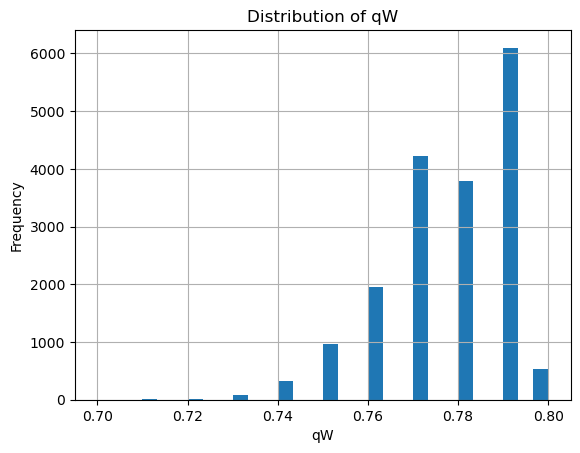

In [54]:
df["qW"].hist(bins = 30)
plt.xlabel("qW")
plt.ylabel("Frequency")
plt.title("Distribution of qW")
plt.show()

This histogram shows the distribution of most qW values seems to fall between approximately 0.77 and 0.79 and this meaning that the majority of WEC farm layouts achieve high interaction efficiency. There's only a small number of layouts have lower qW values showing that inefficient configurations are uncommon in the dataset. 

In [56]:
df_fe = add_geometry_features(df, n_devices = 49)

coord_cols = [
    col for col in df_fe.columns
    if col.startswith("X") or col.startswith("Y")
]

geometry_cols = [
    "centroid_x",
    "centroid_y",
    "x_std",
    "y_std",
    "x_range",
    "y_range",
    "mean_dist_center",
    "max_dist_center"
]

X = df_fe[coord_cols + geometry_cols]
y = df_fe["qW"]

# split after rebuilding X
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42
)

# retrain HGB on the qW target
hgb_qw = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

hgb_qw_results = evaluate_model(
    hgb_qw,
    X_train, y_train,
    X_val, y_val,
    "Hist Gradient Boosting with Geometry Features for qW"
)

hgb_qw_results

{'Model': 'Hist Gradient Boosting with Geometry Features for qW',
 'Train MAE': np.float64(0.0012883995114570238),
 'Val MAE': np.float64(0.0015196975523002903),
 'Train RMSE': np.float64(0.0020121912375369875),
 'Val RMSE': np.float64(0.002440208214917889),
 'Train R2': 0.9789006339201676,
 'Val R2': 0.9705562880614793}

Farm interaction efficiency (qW) is also strongly influenced by the spatial arrangement of the devices. The Hist Gradient Boosting model achieved a validation R² of 0.971 showing that the geometry-based features explain most of the variation in qW.

The results means that turbine placement plays an important role in determining both Total_Power and qW. Although qW reflects more of the complex interactions between the converters, the strong model performance suggests that much of this behavior can be captured using the geometric layout features.

In [57]:
# Random Forest for interpretability
rf_qw = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_qw.fit(X_train, y_train)

importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_qw.feature_importances_
})

importances.sort_values(
    "Importance",
    ascending=False
).head(15)

,Feature,Importance
100,x_std,0.445413
104,mean_dist_center,0.396663
101,y_std,0.030546
102,x_range,0.022432
0,X1,0.006870
46,X24,0.005625
51,Y26,0.005027
6,X4,0.004697
98,centroid_x,0.004068
105,max_dist_center,0.003713


Feature importance for qW was evaluated using a Random Forest model because it provided an easier way to measure the feature importance. While Hist Gradient Boosting was used as the main predictive model, the Random Forest results helped identify which geometry features contributed most to the interaction efficiency.


The feature importance analysis for qW reveals a pattern that is very similar to the Total_Power model. The most influential variables are x_std and mean_dist_center and together they account for more than 84% of the model's total importance.

Then this suggest that interaction efficiency is again strongly influenced by the spatial dispersion of turbines within the farm. The features describing the farm spread and turbine spacing are much more important than any individual turbine coordinates, indicating that the structure plays a dominant role in determining both the qW and Total_Power.

## 11. PCA Analysis

In [58]:
# Return to the main target variable
y = df_fe["Total_Power"]

X = df_fe[coord_cols + geometry_cols]

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

print("Original features:", X.shape[1])
print("PCA features:", X_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

Original features: 106
PCA features: 13
Explained variance: 0.9576192929895514


PCA reduced the feature space from 106 features to 13 principal components while keeping around 95.76% of the original variance. This shows that the coordinate and geometry features contain overlapping information.

In [59]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.15,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=42
)

hgb_pca = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

pca_results = evaluate_model(
    hgb_pca,
    X_train,
    y_train,
    X_val,
    y_val,
    "HGB + PCA"
)

pd.DataFrame([pca_results])

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2
0,HGB + PCA,3625.396705,6351.667758,7502.400901,14948.642281,0.988563,0.956951


In [60]:
comparison = pd.DataFrame([
    hgb_results,   
    pca_results    
])

comparison

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2
0,Hist Gradient Boosting with Geometry Features,1580.602486,2777.122818,2721.691186,5694.674422,0.998495,0.993753
1,HGB + PCA,3625.396705,6351.667758,7502.400901,14948.642281,0.988563,0.956951


### PCA Comparison Results

PCA reduced the feature space from 106 variables to only 13 principal components while retaining approximately 95.8% of the original variance. However, the model performance decreased noticeably after the dimensionality reduction.

The Hist Gradient Boosting model using engineered geometry features got a validation R² of 0.994 and a validation RMSE of about 5,695. In comparison though, the PCA-based model got a validation R² of 0.957 and a validation RMSE of about 14,949.

This seems to indicate that the geometry features contain important predictive information that isn't fully preserved by the PCA transformation. Although the PCA created a more compact representation of the data, the original engineered geometry features made for better performace and easier to interpret. As a result of this, PCA wasn't used in the final model.

## 12. Final Model Evaluation

In [197]:
df_fe = add_geometry_features(df, n_devices=49)

coord_cols = [
    col for col in df_fe.columns
    if col.startswith("X") or col.startswith("Y")
]

geometry_cols = [
    "centroid_x", "centroid_y",
    "x_std", "y_std",
    "x_range", "y_range",
    "mean_dist_center", "max_dist_center"
]

X = df_fe[coord_cols + geometry_cols]
y = df_fe["Total_Power"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42
)

X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

In [198]:
df_fe = add_geometry_features(df, n_devices=49)

coord_cols = [
    col for col in df_fe.columns
    if col.startswith("X") or col.startswith("Y")
]

geometry_cols = [
    "centroid_x", "centroid_y",
    "x_std", "y_std",
    "x_range", "y_range",
    "mean_dist_center", "max_dist_center"
]

X = df_fe[coord_cols + geometry_cols]
y = df_fe["Total_Power"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42
)

X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

hgb_final = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

hgb_final.fit(X_full_train, y_full_train)

test_preds = hgb_final.predict(X_test)

print("Test MAE:", mean_absolute_error(y_test, test_preds))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_preds)))
print("Test R2:", r2_score(y_test, test_preds))

Test MAE: 2695.068206558819
Test RMSE: 5436.687293442334
Test R2: 0.9942741004663747


In [199]:
final_models = {
    "Random Forest + Geometry": RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        random_state=42,
        n_jobs=1
    ),

    "Hist Gradient Boosting + Geometry": HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
}

final_results = []

for model_name, model in final_models.items():
    model.fit(X_full_train, y_full_train)

    test_preds = model.predict(X_test)

    final_results.append({
        "Model": model_name,
        "Test MAE": mean_absolute_error(y_test, test_preds),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
        "Test R2": r2_score(y_test, test_preds)
    })

final_comparison_df = pd.DataFrame(final_results)

final_comparison_df

,Model,Test MAE,Test RMSE,Test R2
0,Random Forest + Geometry,2429.692770,6983.459008,0.990553
1,Hist Gradient Boosting + Geometry,2695.068207,5436.687293,0.994274


### Results Summary

The table below summarizes validation performance for the primary models evaluated during the study.

| Model | Validation MAE | Validation RMSE | Validation R² |
|---------|---------|---------|---------|
| Dummy Regressor | 59134 | 72098 | -0.001 |
| Linear Regression | 16396 | 23534 | 0.893 |
| Gradient Boosting | 8003 | 12158 | 0.972 |
| Hist Gradient Boosting (Raw Coordinates) | 3488 | 7236 | 0.990 |
| Random Forest (Raw Coordinates) | 3669 | 10285 | 0.980 |
| Random Forest + Geometry Features | 2731 | 7277 | 0.990 |
| Hist Gradient Boosting + Geometry Features | 2777 | 5695 | 0.994 |

### Model Selection

Both Random Forest and Hist Gradient Boosting improved from adding the engineered geometry features. While Random Forest achieved a slightly lower validation MAE, Hist Gradient Boosting produced a lower validation RMSE and a higher validation R² which means the model has fewer large prediction errors and a stronger overall performance.

Because Hist Gradient Boosting also performed consistently well across the cross-validation, dataset generalization, and final testing, it's selected as the final model for predicting Total_Power.

### Final Model Performance

Final Model:
Hist Gradient Boosting with Engineered Geometry Features

| Metric | Test Value |
|----------|----------|
| MAE | 2695.07 |
| RMSE | 5436.69 |
| R² | 0.99427 |

The final Hist Gradient Boosting model was able to achieved a strong performance on the held-out test set, explaining more than 99% of the variation in Total_Power while also maintaining the small prediction errors. The test results were also very similar to what we got with the validation and cross-validation results and displaying that the model generalizes well to unseen WEC farm layouts.

Overall, these results show that the engineered geometry features captures the key spatial characteristics of WEC farm layouts and provide a strong foundation for surrogate modeling.

## 13. Conclusions

This project main purpose is to developed machine learning surrogate models to be able to predict WEC farm performance using turbine layout information. Throughout the notebook, several models were evaluated, such as Linear Regression, Gradient Boosting, Random Forest, and Hist Gradient Boosting. The results from these showed that the tree-based ensemble methods performed much better than the linear models. Meaning that the relationship between the farm layout and power production is largely nonlinear.

Feature engineering turned out to be the most important parts of the project. Geometry-based features such as `x_std` and `mean_dist_center` consistently emerged as the strongest predictors of both Total_Power and qW interaction efficiency. The results seem to suggest that overall turbine spacing and farm layout are more important than the exact location of any individual turbines.

When all the models were tested, Hist Gradient Boosting with engineered geometry features had the best overall performance with the final model achieving a test MAE of 2695.07, a test RMSE of 5436.69, and a test R² of 0.9943. The cross-validation and dataset generalization results also display that the model remained accurate across different farm sizes and locations.

When experimenting with PCA, it successfully reduced the feature space from 106 variables to 13 principal components while retaining most of the original variance. However, the predictive performance decreased largely and is indicating that the engineered geometry features preserved important information that wasn't all captured by the PCA transformation.

The results here show that the engineered geometry features combined with Hist Gradient Boosting provided an accurate and reliable approach for predicting the WEC farm performance. The findings we came across also highlighted the importance of turbine spacing and the overall farm geometry in determining both the power production and interaction efficiency.